In [30]:
import scipy
import matplotlib.pyplot as plt
from dataclasses import dataclass
import numpy

In [89]:
@dataclass(frozen=True)
class InfectionConfig:
    """All the conigures of the infection rate"""
    Infectivity : float = 0.6 
    ContactRateInfectious : float = 1.25
    AvgIncubationTime : float = 10  
    AvgIllnessDur : float = 15
    TotalPopulation : int = 10e3 


def f_SolveInfection(t, vals, IConfig : InfectionConfig):
    Susceptible, Exposed, Infectious, Recovered = vals

    dtExposedRate =  IConfig.ContactRateInfectious * Infectious * IConfig.Infectivity * Susceptible / IConfig.TotalPopulation
    dtInfectiosRate = Exposed / IConfig.AvgIncubationTime 
    dtRecovered = Infectious / IConfig.AvgIllnessDur
    
    dSuscpetible = -dtExposedRate
    dExposed = dtExposedRate - dtInfectiosRate
    dInfectious = dtInfectiosRate - dtRecovered
    dRecovered = dtRecovered
    
    return [dSuscpetible, dExposed, dInfectious, dRecovered]


labels = ["Susceptible", "Exposed", "Infectious", "Recovered"]
colors = ["blue", "orange", "red", "green"]


In [100]:
IConfig = InfectionConfig()

tspan = numpy.linspace(0,150,1000)

#     Susceptible,                  Exposed,   Infectious,  Recovered
y0 = [IConfig.TotalPopulation-1,    0,         1,           0          ]


Results = scipy.integrate.solve_ivp(f_SolveInfection, (tspan[0], tspan[-1]), y0, args=(IConfig,) , t_eval=tspan)

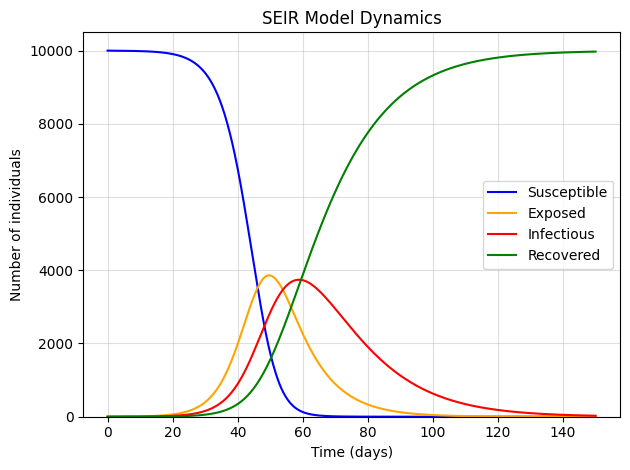

In [126]:
for i, (l,c) in enumerate(zip(labels, colors)):
    plt.plot(Results.t, Results.y[i], label=l, color=c)

plt.legend()
plt.ylabel("Number of individuals")
plt.xlabel("Time (days)")
plt.title("SEIR Model Dynamics")
plt.grid(alpha=0.4)
plt.tight_layout() # dam plotting without this thing
plt.ylim(bottom=-0.1)
plt.savefig("Figures//SEIR-Python.png")
plt.show()